In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('/Users/ryan.oliveira/Desktop/puc/ppl-cd-pcd-sist-int-2025-1-grupo-5-2025-1/assets/data/hip_salario_planilha_tratada.csv')

In [3]:
df.drop(['faixa_salarial'], axis=1)

,uf_onde_mora,sql,nao_utiliza_linguagem,python,linguagens_estatisticas_analise_dados,linguagens_web,linguagens_empresariais,linguagens_sistemas,salario_medio
0,MG,1.0,0.0,1.0,0,0,0,0,14000.500000
1,ES,1.0,0.0,1.0,0,0,0,0,7000.500000
2,SP,1.0,0.0,1.0,1,0,0,0,7000.500000
3,SP,0.0,0.0,0.0,0,0,0,0,10576.036406
4,MG,1.0,0.0,1.0,0,0,0,0,5000.500000
...,...,...,...,...,...,...,...,...,...
5288,MG,0.0,0.0,0.0,0,0,0,0,22500.500000
5289,RN,1.0,0.0,1.0,0,0,0,0,10000.500000
5290,SP,1.0,0.0,1.0,0,0,0,0,10000.500000
5291,SP,0.0,0.0,0.0,0,0,0,0,10576.036406


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5293 entries, 0 to 5292
Data columns (total 10 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   uf_onde_mora                           5293 non-null   object 
 1   faixa_salarial                         5293 non-null   object 
 2   sql                                    5293 non-null   float64
 3   nao_utiliza_linguagem                  5293 non-null   float64
 4   python                                 5293 non-null   float64
 5   linguagens_estatisticas_analise_dados  5293 non-null   int64  
 6   linguagens_web                         5293 non-null   int64  
 7   linguagens_empresariais                5293 non-null   int64  
 8   linguagens_sistemas                    5293 non-null   int64  
 9   salario_medio                          5293 non-null   float64
dtypes: float64(4), int64(4), object(2)
memory usage: 413.6+ KB


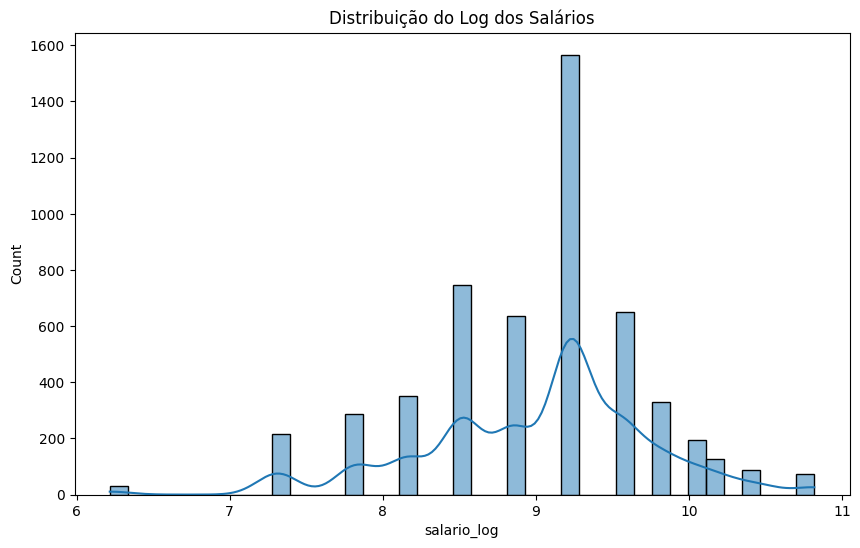

In [5]:
categorical_cols = ['uf_onde_mora']
numeric_cols = df.drop(columns=categorical_cols + ['salario_medio']).columns

# Transformação logarítmica da variável alvo (para normalizar a distribuição)
df['salario_log'] = np.log1p(df['salario_medio'])

# Plotando a distribuição transformada
plt.figure(figsize=(10, 6))
sns.histplot(df['salario_log'], kde=True)
plt.title('Distribuição do Log dos Salários')
plt.show()

In [6]:
# Calculando limites para outliers (método IQR)
Q1 = df['salario_medio'].quantile(0.25)
Q3 = df['salario_medio'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filtrando outliers extremos
df_filtered = df[(df['salario_medio'] >= lower_bound) & (df['salario_medio'] <= upper_bound)]
print(f"Registros removidos: {len(df) - len(df_filtered)}")

# 4. Preparação para o modelo
X = df_filtered.drop(['salario_medio', 'salario_log'], axis=1)
y = df_filtered['salario_log']  # Usando o salário transformado

Registros removidos: 158


In [7]:
# 5. Split com proporção mais adequada
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [8]:
# 6. Criação de pipeline com pré-processamento
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
    ],
    remainder='passthrough'
)

In [9]:
# 7. Ajuste de hiperparâmetros usando RandomizedSearchCV
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(random_state=42, oob_score=True))
])

In [10]:
# Busca aleatória de hiperparâmetros
rf_search = RandomizedSearchCV(
    rf_pipeline, 
    param_distributions={f'model__{key}': value for key, value in param_grid.items()},
    n_iter=20, 
    cv=5, 
    scoring='r2',
    random_state=42
)

In [11]:
# Treinamento do modelo otimizado
rf_search.fit(X_train, y_train)

# Avaliação do modelo
best_rf_model = rf_search.best_estimator_
predictions = best_rf_model.predict(X_test)

# Revertendo a transformação logarítmica para métricas reais
y_test_original = np.expm1(y_test)
predictions_original = np.expm1(predictions)

# Métricas nos dados transformados
r2_log = r2_score(y_test, predictions)
mse_log = mean_squared_error(y_test, predictions)

# Métricas nos dados originais
r2_original = r2_score(y_test_original, predictions_original)
mse_original = mean_squared_error(y_test_original, predictions_original)

print("\n=== Resultados do Modelo Random Forest Otimizado ===")
print(f'Melhores hiperparâmetros: {rf_search.best_params_}')
print(f'R-squared (dados transformados): {r2_log:.4f}')
print(f'R-squared (dados originais): {r2_original:.4f}')
print(f'MSE (dados originais): {mse_original:.2f}')


ValueError: 
All the 100 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
20 fits failed with the following error:
Traceback (most recent call last):
  File "/Users/ryan.oliveira/Desktop/puc/ppl-cd-pcd-sist-int-2025-1-grupo-5-2025-1/venv/lib/python3.13/site-packages/sklearn/compose/_column_transformer.py", line 1136, in _hstack
    check_array(X, accept_sparse=True, ensure_all_finite=False)
    ~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/ryan.oliveira/Desktop/puc/ppl-cd-pcd-sist-int-2025-1-grupo-5-2025-1/venv/lib/python3.13/site-packages/sklearn/utils/validation.py", line 1055, in check_array
    array = _asarray_with_order(array, order=order, dtype=dtype, xp=xp)
  File "/Users/ryan.oliveira/Desktop/puc/ppl-cd-pcd-sist-int-2025-1-grupo-5-2025-1/venv/lib/p

1. Análise exploratória: Visualização da distribuição salarial e correlações
2. Tratamento adequado das variáveis categóricas: Usando OneHotEncoder no pipeline
3. Transformação logarítmica dos salários: Para normalizar a distribuição
4. Remoção de outliers: Usando o método IQR para identificar valores extremos
5. Split de dados mais adequado: 80% treino / 20% teste
6. Otimização de hiperparâmetros: Usando RandomizedSearchCV


=== Top Features Numéricas Mais Importantes ===
1. nao_utiliza_linguagem: 0.2898
2. python: 0.2642
3. sql: 0.2601
4. linguagens_estatisticas_analise_dados: 0.0670
5. linguagens_empresariais: 0.0664
6. linguagens_sistemas: 0.0274
7. linguagens_web: 0.0250


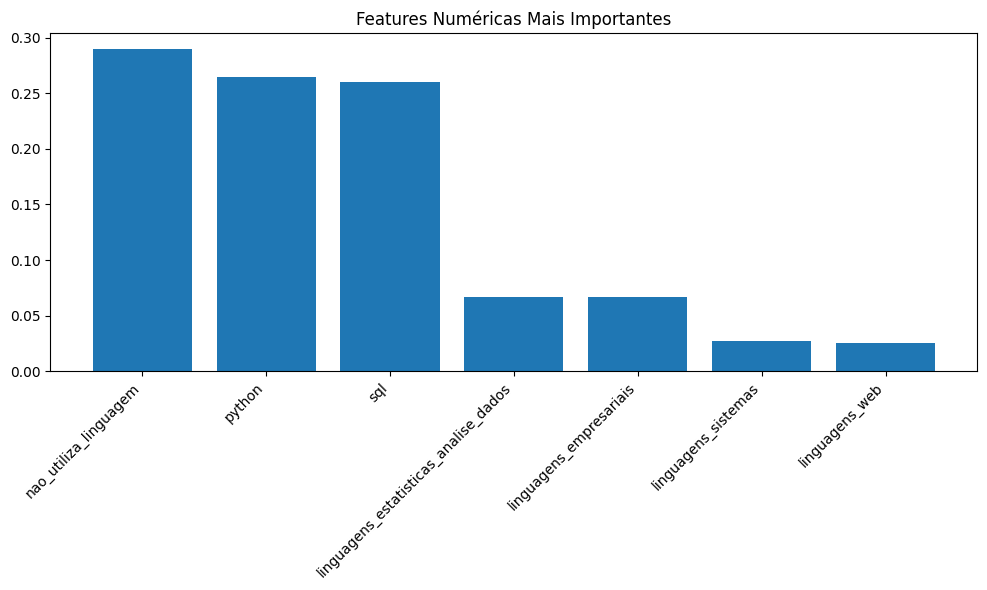

In [110]:
# Solução 1: Usar apenas as colunas numéricas para visualização
X_train_numeric = X_train.select_dtypes(include=['number'])

# Treinar um modelo RandomForest com as variáveis numéricas
rf_viz = RandomForestRegressor(n_estimators=100, random_state=42)
rf_viz.fit(X_train_numeric, y_train)

# Visualizar importâncias
importances = rf_viz.feature_importances_
indices = np.argsort(importances)[::-1]

# Mostrar top features
print("\n=== Top Features Numéricas Mais Importantes ===")
for i in range(len(X_train_numeric.columns)):
    print(f"{i+1}. {X_train_numeric.columns[indices[i]]}: {importances[indices[i]]:.4f}")

# Gráfico
plt.figure(figsize=(10, 6))
plt.title('Features Numéricas Mais Importantes')
plt.bar(range(len(X_train_numeric.columns)), importances[indices])
plt.xticks(range(len(X_train_numeric.columns)), 
          [X_train_numeric.columns[i] for i in indices], 
          rotation=45, ha='right')
plt.tight_layout()
plt.show()